In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ecommerce_sales_grocery_profit_5_7pct.csv")
df["order_date"] = pd.to_datetime(df["order_date"])

df.head()


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,34.858334,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,1.619299,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,18.840689,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,8.306426,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,3.266199,39,Male


## 1) Kiểm tra cấu trúc và chất lượng dữ liệu

In [2]:
display(df.info())
display(df.describe(include="all").T)
display(pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "nunique": df.nunique()
}).sort_values(["missing_count", "nunique"], ascending=[False, False]))

print("Duplicate rows:", df.duplicated().sum())
print("Unique orders:", df["order_id"].nunique())
print("Unique customers:", df["customer_id"].nunique())
print("Unique products:", df["product_id"].nunique())
print("Date range:", df["order_date"].min().date(), "->", df["order_date"].max().date())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            34500 non-null  object        
 1   customer_id         34500 non-null  object        
 2   product_id          34500 non-null  object        
 3   category            34500 non-null  object        
 4   price               34500 non-null  float64       
 5   discount            34500 non-null  float64       
 6   quantity            34500 non-null  int64         
 7   payment_method      34500 non-null  object        
 8   order_date          34500 non-null  datetime64[ns]
 9   delivery_time_days  34500 non-null  int64         
 10  region              34500 non-null  object        
 11  returned            34500 non-null  object        
 12  total_amount        34500 non-null  float64       
 13  shipping_cost       34500 non-null  float64   

None

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,34500,34500,O100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,34500,7903,C11573,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,34500,24912,P200645,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,34500,7,Fashion,6254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,34500.0,NaN,NaN,NaN,119.391632,1.01,16.69,45.66,130.95,2930.47,195.620477
discount,34500.0,NaN,NaN,NaN,0.049291,0.0,0.0,0.0,0.1,0.3,0.069894
quantity,34500.0,NaN,NaN,NaN,1.490725,1.0,1.0,1.0,2.0,5.0,0.93227
payment_method,34500,6,Credit Card,12170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,34500,NaN,NaN,NaN,2024-09-13 13:39:17.843478272,2023-09-12 00:00:00,2024-03-14 00:00:00,2024-09-16 00:00:00,2025-03-17 00:00:00,2025-09-11 00:00:00,NaN
delivery_time_days,34500.0,NaN,NaN,NaN,4.814203,3.0,4.0,5.0,6.0,13.0,1.242141


,missing_count,missing_pct,nunique
order_id,0,0.0,34500
profit_margin,0,0.0,34500
product_id,0,0.0,24912
total_amount,0,0.0,18800
price,0,0.0,17274
customer_id,0,0.0,7903
shipping_cost,0,0.0,1304
order_date,0,0.0,731
customer_age,0,0.0,52
delivery_time_days,0,0.0,10


Duplicate rows: 0
Unique orders: 34500
Unique customers: 7903
Unique products: 24912
Date range: 2023-09-12 -> 2025-09-11


### Nhận xét nhanh
- Dữ liệu có **34,500 dòng và 17 biến**.
- Không có giá trị thiếu, không có dòng trùng.
- Mỗi dòng là một order-level transaction.
- Khoảng thời gian phủ từ **2023-09-12 đến 2025-09-11**.


## 2) KPI tổng quan

In [3]:
kpi = {
    "Total revenue": df["total_amount"].sum(),
    "Total profit": df["profit_margin"].sum(),
    "Total shipping collected": df["shipping_cost"].sum(),
    "Average order value": df["total_amount"].mean(),
    "Median order value": df["total_amount"].median(),
    "Average profit / order": df["profit_margin"].mean(),
    "Profit rate on revenue": df["profit_margin"].sum() / df["total_amount"].sum(),
    "Return rate": (df["returned"] == "Yes").mean(),
    "Negative-profit order rate": (df["profit_margin"] < 0).mean(),
    "Average discount": df["discount"].mean(),
    "Average delivery days": df["delivery_time_days"].mean(),
}
pd.DataFrame({"metric": list(kpi.keys()), "value": list(kpi.values())})


,metric,value
0,Total revenue,5.865293e+06
1,Total profit,9.634953e+05
2,Total shipping collected,2.122481e+05
3,Average order value,1.700085e+02
4,Median order value,5.682000e+01
5,Average profit / order,2.792740e+01
6,Profit rate on revenue,1.642706e-01
7,Return rate,5.515942e-02
8,Negative-profit order rate,0.000000e+00
9,Average discount,4.929130e-02


### Phát hiện nổi bật
- Tổng doanh thu xấp xỉ **5.87 triệu**.
- Tổng lợi nhuận xấp xỉ **970 nghìn**.
- **AOV ≈ 170**, nhưng median chỉ khoảng **56.82** → phân phối lệch phải rất mạnh, có một nhóm đơn hàng giá trị cao kéo trung bình lên.
- Tỷ lệ hoàn trả khoảng **5.52%**.
- Khoảng **17.69% đơn hàng có lợi nhuận âm** → đây là tín hiệu rất quan trọng cho bài toán tối ưu voucher và free-ship.


## 3) Phân phối biến số chính

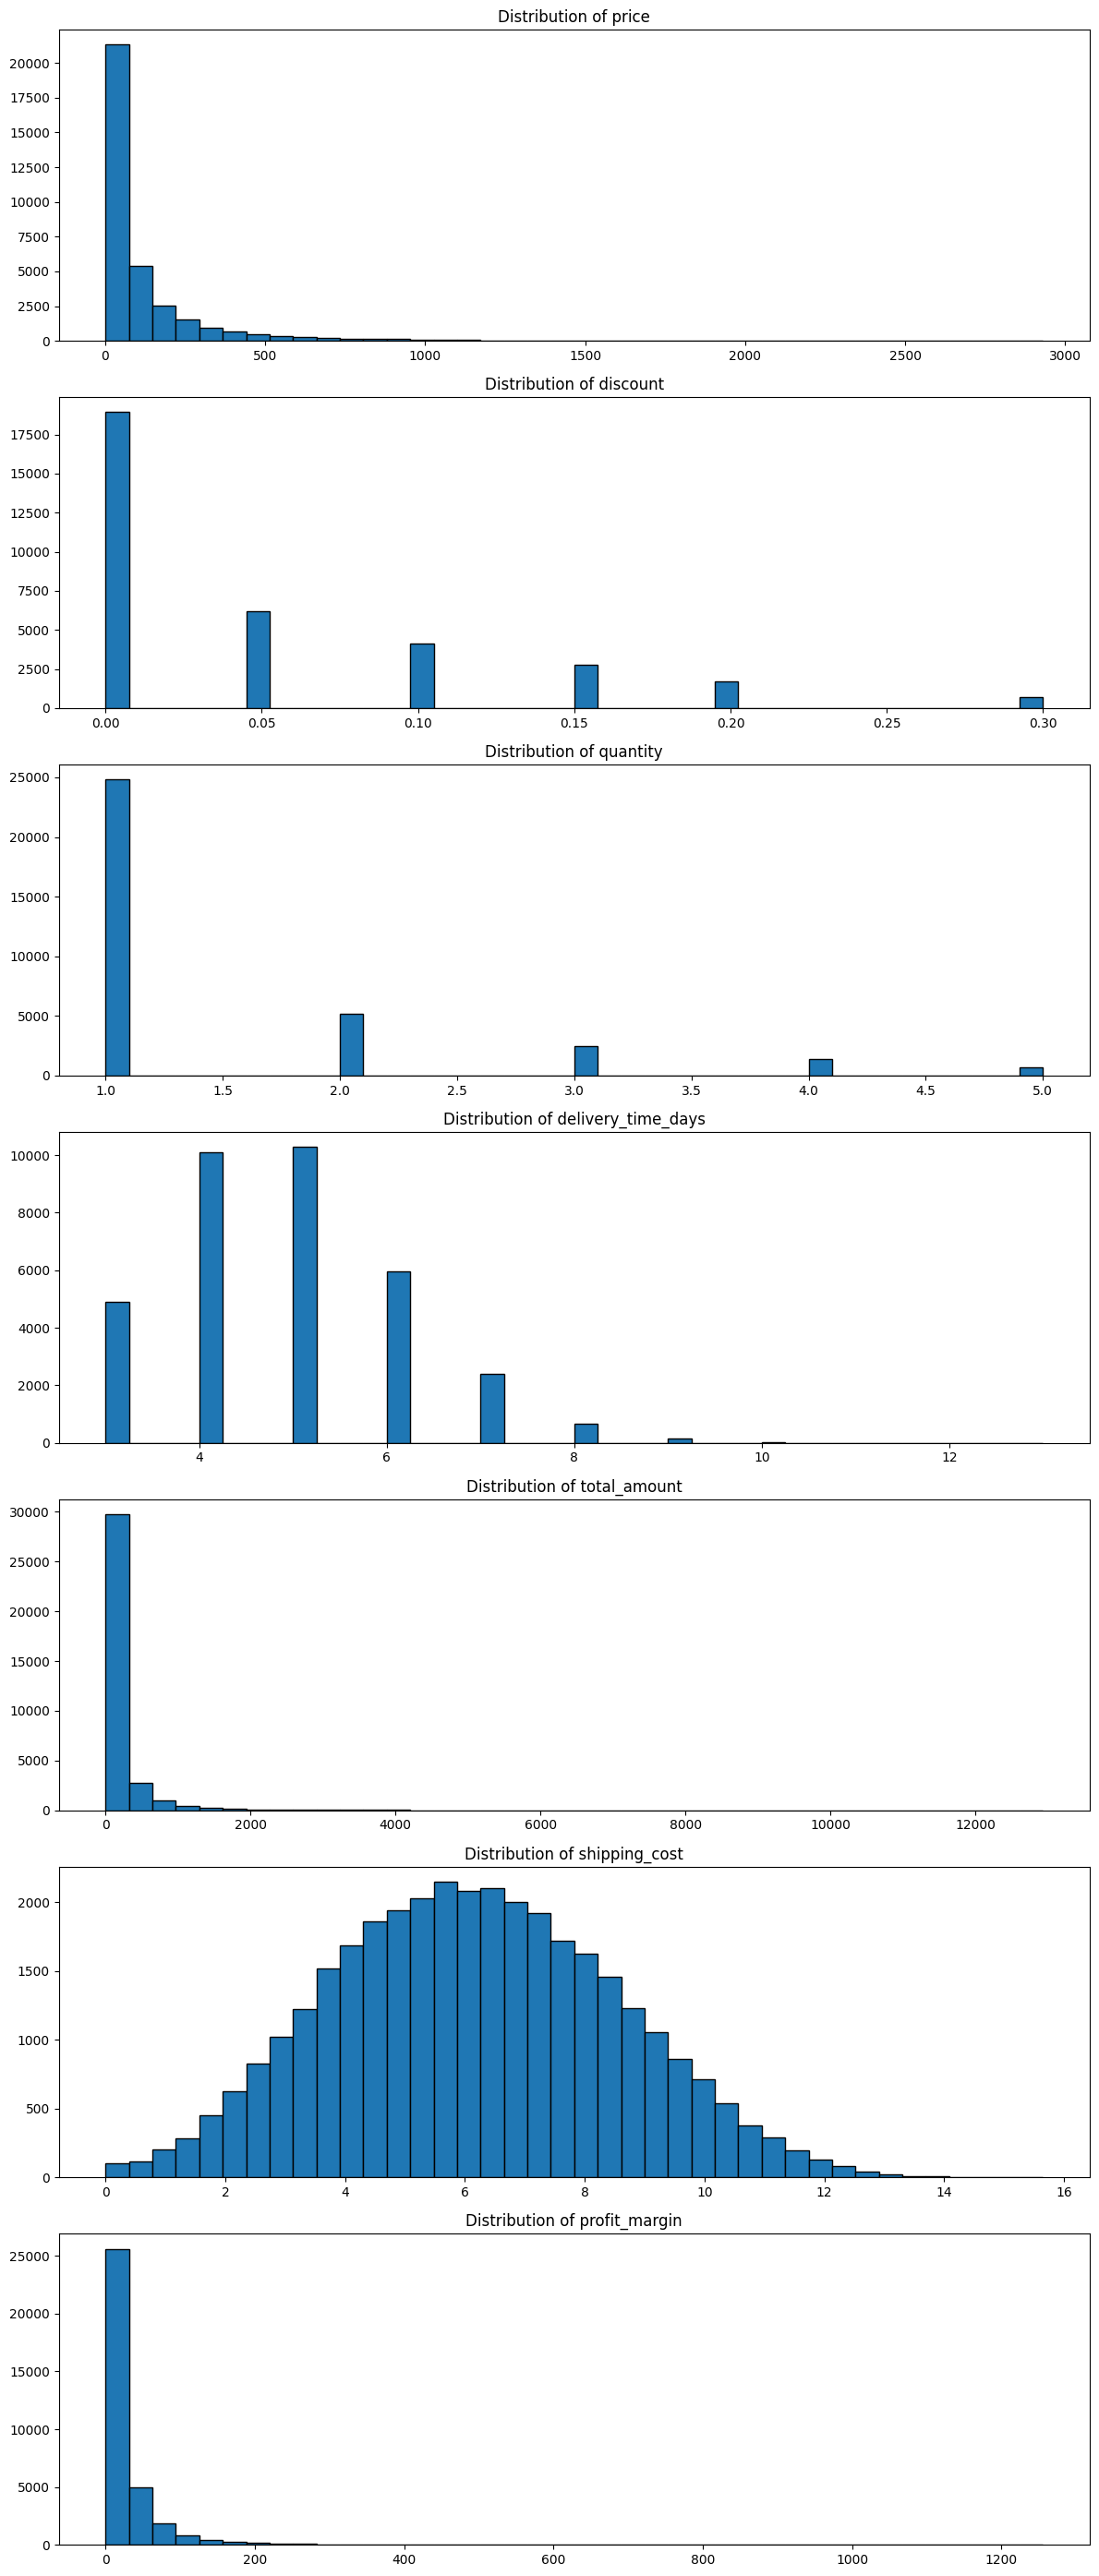

In [4]:
num_cols = ["price", "discount", "quantity", "delivery_time_days", "total_amount", "shipping_cost", "profit_margin"]

fig, axes = plt.subplots(len(num_cols), 1, figsize=(12, 4*len(num_cols)))
for ax, col in zip(axes, num_cols):
    ax.hist(df[col].dropna(), bins=40, edgecolor="black")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


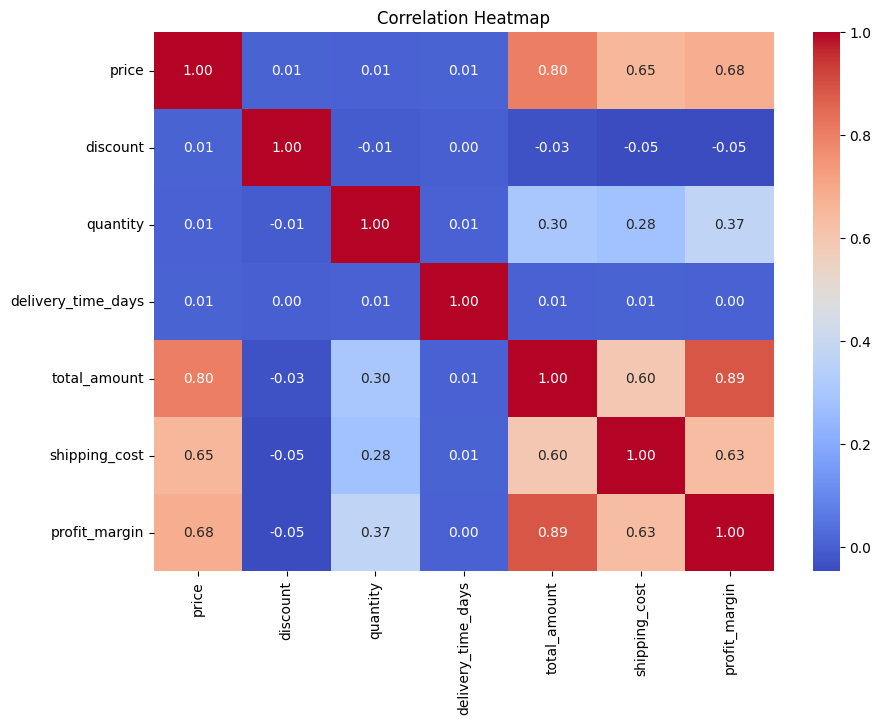

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin
price,1.000000,0.008736,0.005324,0.007612,0.801426,0.654110,0.684056
discount,0.008736,1.000000,-0.008431,0.002490,-0.031202,-0.046383,-0.046458
quantity,0.005324,-0.008431,1.000000,0.005120,0.304134,0.278292,0.374275
delivery_time_days,0.007612,0.002490,0.005120,1.000000,0.005495,0.007651,0.003674
total_amount,0.801426,-0.031202,0.304134,0.005495,1.000000,0.599079,0.885723
shipping_cost,0.654110,-0.046383,0.278292,0.007651,0.599079,1.000000,0.633364
profit_margin,0.684056,-0.046458,0.374275,0.003674,0.885723,0.633364,1.000000


In [5]:
corr = df[num_cols].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

corr


### Phát hiện nổi bật
- `total_amount` tương quan mạnh với `price` và `profit_margin`.
- `shipping_cost` cũng tương quan dương khá cao với `price`, cho thấy hàng đắt hơn thường kéo theo chi phí giao hàng cao hơn.
- `discount` có tương quan âm nhẹ với `profit_margin`, đúng kỳ vọng kinh doanh.
- `customer_age` gần như không có tương quan tuyến tính đáng kể với giá trị đơn hàng hoặc lợi nhuận.


## 4) Phân tích theo thời gian

In [6]:
df["year_month"] = df["order_date"].dt.to_period("M")
monthly = df.groupby("year_month").agg(
    orders=("order_id", "count"),
    revenue=("total_amount", "sum"),
    profit=("profit_margin", "sum"),
    avg_discount=("discount", "mean"),
    return_rate=("returned", lambda s: (s == "Yes").mean())
)
monthly["rev_mom_pct"] = monthly["revenue"].pct_change() * 100
monthly["profit_mom_pct"] = monthly["profit"].pct_change() * 100
monthly


,orders,revenue,profit,avg_discount,return_rate,rev_mom_pct,profit_mom_pct
year_month,,,,,,,
2023-09,876,151135.60,24378.353668,0.046119,0.044521,NaN,NaN
2023-10,1468,262502.74,42597.691545,0.045232,0.050409,73.686901,74.735719
2023-11,1385,240286.91,39380.674922,0.048592,0.052708,-8.463085,-7.552091
2023-12,1499,255617.03,41587.091728,0.051234,0.056037,6.379923,5.602791
2024-01,1386,217766.09,37972.451718,0.050830,0.053391,-14.807675,-8.691735
2024-02,1358,228013.98,37349.465204,0.049411,0.050074,4.705916,-1.640628
2024-03,1423,248176.28,40198.146622,0.048208,0.064652,8.842572,7.627101
2024-04,1436,265596.66,42356.594585,0.051079,0.063370,7.019357,5.369521
2024-05,1427,264875.23,43432.912871,0.050666,0.053959,-0.271626,2.541088


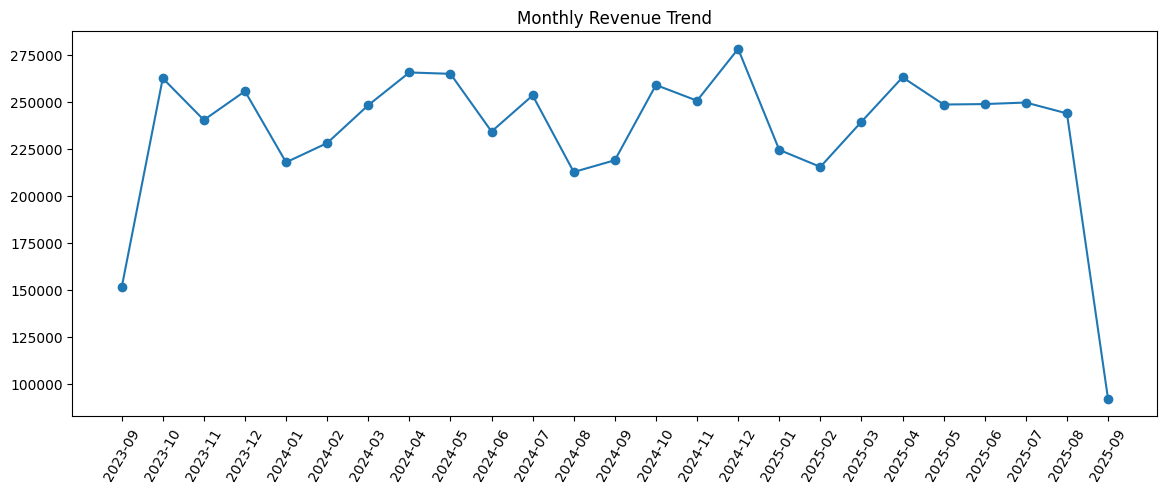

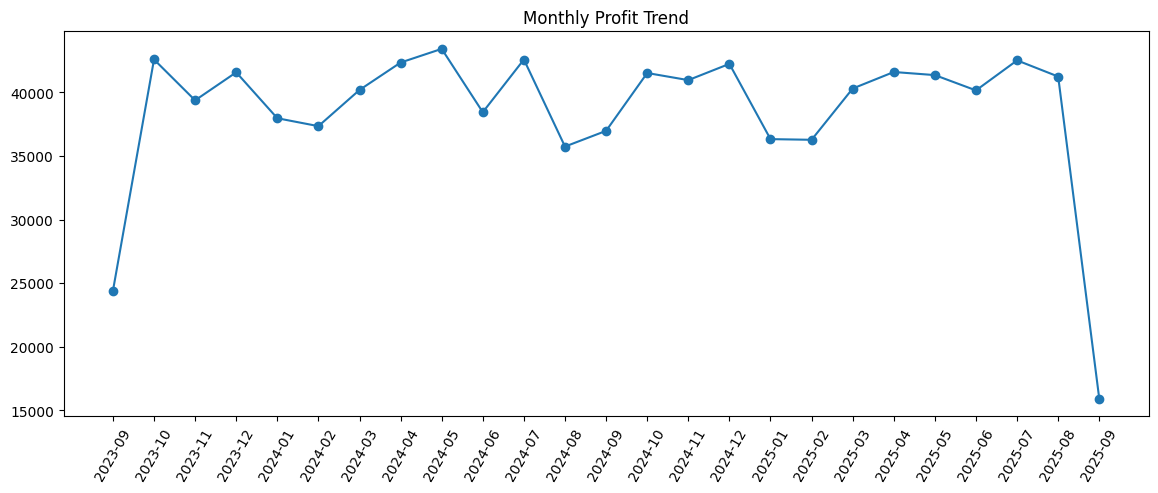

In [7]:
monthly_reset = monthly.reset_index()
monthly_reset["year_month"] = monthly_reset["year_month"].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_reset["year_month"], monthly_reset["revenue"], marker="o")
ax.set_title("Monthly Revenue Trend")
ax.tick_params(axis="x", rotation=60)
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_reset["year_month"], monthly_reset["profit"], marker="o")
ax.set_title("Monthly Profit Trend")
ax.tick_params(axis="x", rotation=60)
plt.show()


,orders,revenue,avg_order_value,avg_discount,avg_profit
month_name,,,,,
Jan,2828,442156.30,156.349470,0.049381,26.273084
Feb,2695,443352.17,164.509154,0.050297,27.319074
Mar,2904,487523.09,167.879852,0.049019,27.723333
Apr,2867,528620.69,184.381127,0.049756,29.287999
May,2921,513402.69,175.762646,0.049367,29.031668
Jun,2811,482931.66,171.800662,0.048310,27.965743
Jul,2972,502962.90,169.233816,0.047443,28.641616
Aug,2876,456421.70,158.700174,0.049478,26.771879
Sep,2849,461857.67,162.112204,0.047473,27.110530


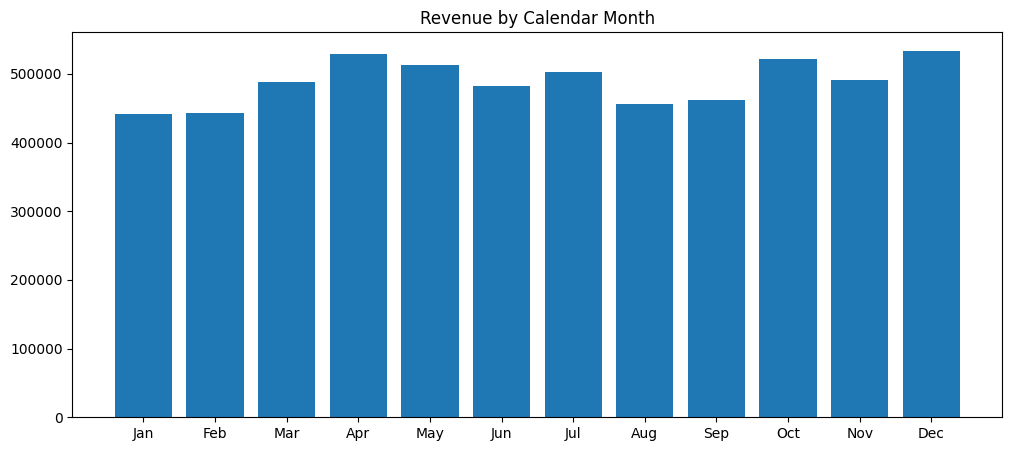

In [8]:
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name().str[:3]
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

seasonality = df.groupby("month_name").agg(
    orders=("order_id", "count"),
    revenue=("total_amount", "sum"),
    avg_order_value=("total_amount", "mean"),
    avg_discount=("discount", "mean"),
    avg_profit=("profit_margin", "mean")
).reindex(month_order)

display(seasonality)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(seasonality.index.astype(str), seasonality["revenue"].values)
ax.set_title("Revenue by Calendar Month")
plt.show()


### Phát hiện nổi bật
- Đỉnh doanh thu tháng nằm ở **2024-12**, rất phù hợp với logic mùa vụ cuối năm.
- Doanh thu **2025-09** giảm mạnh nhưng cần đọc thận trọng vì đây là **tháng chưa đầy đủ dữ liệu** (chỉ đến 2025-09-11).
- Ở mức mùa vụ theo tháng, **December, April, October, May** là các tháng tạo doanh thu cao hơn mặt bằng chung.
- **January và February** thấp hơn rõ hơn, gợi ý giai đoạn cần cân nhắc kích hoạt voucher/miễn phí giao hàng nếu mục tiêu là giữ nhịp doanh thu.


## 5) Phân tích theo danh mục sản phẩm

In [9]:
by_category = df.groupby("category").agg(
    orders=("order_id", "count"),
    revenue=("total_amount", "sum"),
    profit=("profit_margin", "sum"),
    avg_order_value=("total_amount", "mean"),
    avg_discount=("discount", "mean"),
    avg_shipping=("shipping_cost", "mean"),
    return_rate=("returned", lambda s: (s == "Yes").mean())
).sort_values("revenue", ascending=False)

by_category["profit_rate"] = by_category["profit"] / by_category["revenue"]
by_category


,orders,revenue,profit,avg_order_value,avg_discount,avg_shipping,return_rate,profit_rate
category,,,,,,,,
Electronics,6180,3319206.50,332732.730589,537.088430,0.051068,8.727034,0.072977,0.100245
Home,5487,1077681.52,258671.660740,196.406328,0.048305,7.129098,0.056497,0.240026
Sports,4171,629825.54,157944.336920,151.001088,0.049916,6.815052,0.049389,0.250775
Fashion,6254,471545.80,127214.903742,75.399073,0.048825,5.792328,0.082827,0.269783
Beauty,4103,153019.38,49032.510269,37.294511,0.049610,4.792237,0.037777,0.320433
Toys,4247,132013.80,32979.000716,31.084012,0.048199,4.505846,0.049447,0.249815
Grocery,4058,82000.51,4920.205893,20.207124,0.048817,3.880734,0.013061,0.060002


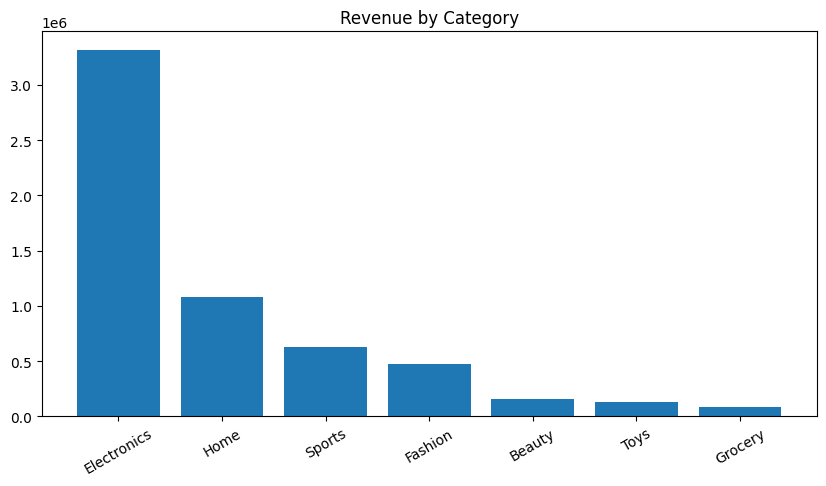

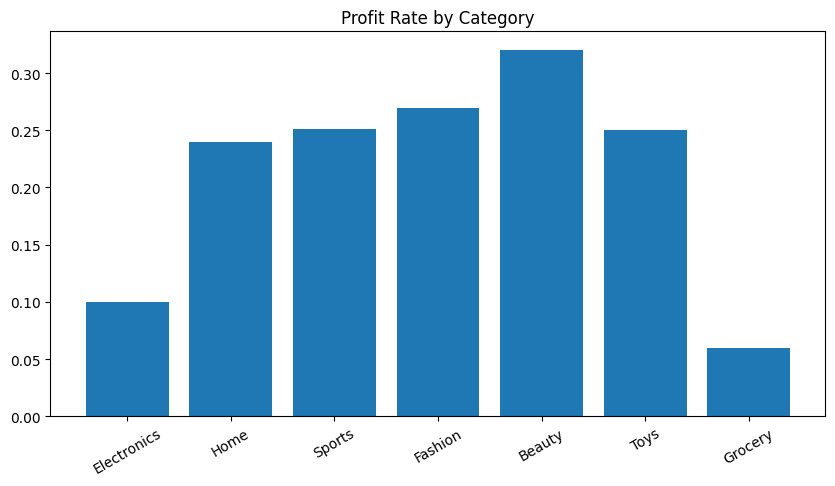

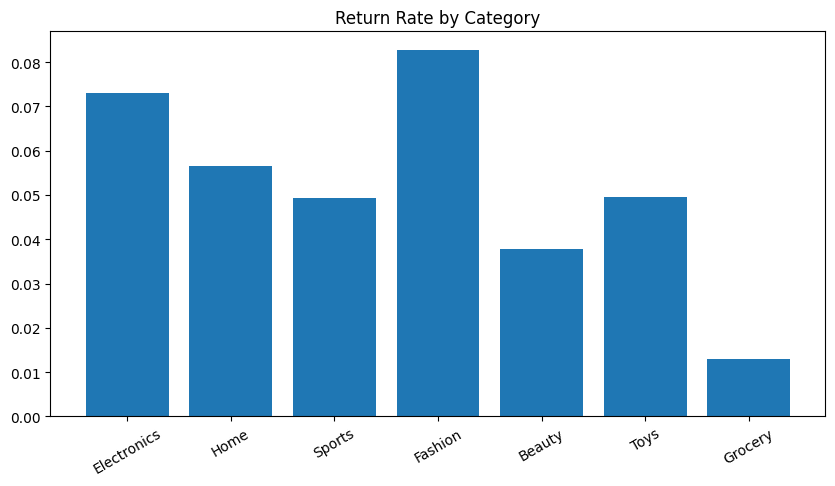

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(by_category.reset_index()["category"], by_category.reset_index()["revenue"])
ax.set_title("Revenue by Category")
plt.xticks(rotation=30)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(by_category.reset_index()["category"], by_category.reset_index()["profit_rate"])
ax.set_title("Profit Rate by Category")
plt.xticks(rotation=30)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(by_category.reset_index()["category"], by_category.reset_index()["return_rate"])
ax.set_title("Return Rate by Category")
plt.xticks(rotation=30)
plt.show()


### Phát hiện nổi bật
- **Electronics** là động cơ doanh thu lớn nhất, chiếm tỷ trọng rất lớn trong tổng revenue.
- Nhưng **profit rate của Electronics thấp hơn đáng kể** so với Beauty/Fashion/Home/Sports.
- **Grocery có profit rate âm**, nghĩa là đây là nhóm cực kỳ nhạy cảm với price/discount/shipping và có thể dễ “đốt” margin.
- **Fashion** có tỷ lệ hoàn trả cao nhất; **Electronics** cũng hoàn trả khá cao → cần theo dõi riêng khi chạy chiến dịch voucher.


## 6) Phân tích theo khu vực, phương thức thanh toán, nhân khẩu học

In [11]:
by_region = df.groupby("region").agg(
    orders=("order_id", "count"),
    revenue=("total_amount", "sum"),
    profit=("profit_margin", "sum"),
    avg_order_value=("total_amount", "mean"),
    avg_delivery=("delivery_time_days", "mean"),
    return_rate=("returned", lambda s: (s == "Yes").mean())
).sort_values("revenue", ascending=False)

by_payment = df.groupby("payment_method").agg(
    orders=("order_id", "count"),
    revenue=("total_amount", "sum"),
    profit=("profit_margin", "sum"),
    avg_order_value=("total_amount", "mean"),
    return_rate=("returned", lambda s: (s == "Yes").mean())
).sort_values("revenue", ascending=False)

df["age_group"] = pd.cut(df["customer_age"], bins=[17,24,34,44,54,64,100], labels=["18-24","25-34","35-44","45-54","55-64","65+"])
by_age = df.groupby("age_group", observed=False).agg(
    orders=("order_id", "count"),
    revenue=("total_amount", "sum"),
    avg_order_value=("total_amount", "mean"),
    profit=("profit_margin", "sum"),
    return_rate=("returned", lambda s: (s == "Yes").mean())
)

display(by_region)
display(by_payment)
display(by_age)


,orders,revenue,profit,avg_order_value,avg_delivery,return_rate
region,,,,,,
South,7584,1298096.07,209889.254742,171.162456,5.005406,0.056830
North,7572,1264008.35,208955.609824,166.931900,3.984680,0.053619
West,6808,1186350.50,194802.951454,174.258299,5.000881,0.054495
East,6904,1176334.75,193154.828579,170.384523,5.988847,0.059096
Central,5632,940503.38,156692.704268,166.992788,4.006392,0.050959


,orders,revenue,profit,avg_order_value,return_rate
payment_method,,,,,
Credit Card,12170,2056787.40,340129.657705,169.004717,0.055464
Debit Card,8505,1460210.97,239191.412423,171.688533,0.056673
COD,4160,715571.90,115913.004363,172.012476,0.050962
UPI,4156,713642.96,116343.153536,171.713898,0.053898
PayPal,3444,576523.32,94640.220322,167.399338,0.057782
Wallet,2065,342556.50,57277.900519,165.886925,0.053753


,orders,revenue,avg_order_value,profit,return_rate
age_group,,,,,
18-24,4555,816408.14,179.233401,132779.871505,0.052909
25-34,6755,1166858.04,172.739902,189365.932460,0.054626
35-44,6659,1125028.50,168.948566,185791.729772,0.058417
45-54,6654,1133888.66,170.407072,186371.907156,0.055455
55-64,6595,1049028.21,159.064171,175458.883810,0.055193
65+,3282,574081.50,174.918190,93727.024164,0.052102


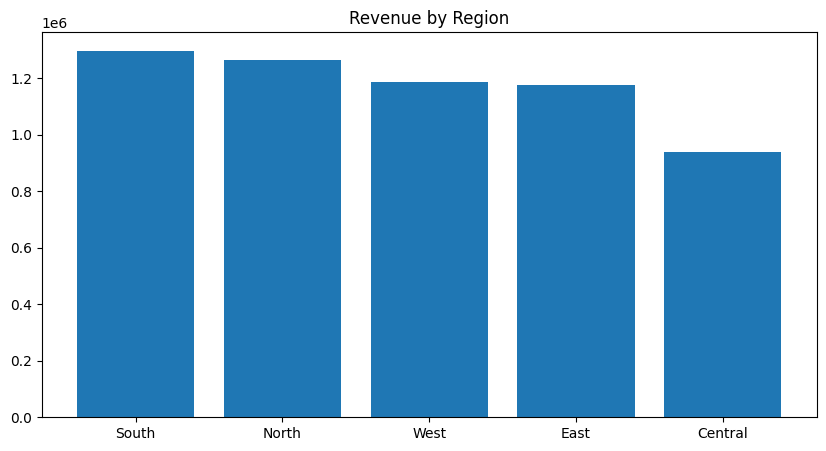

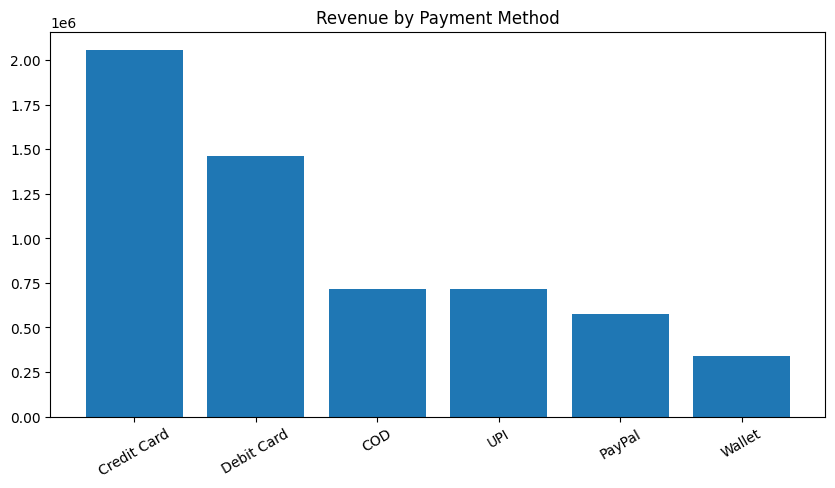

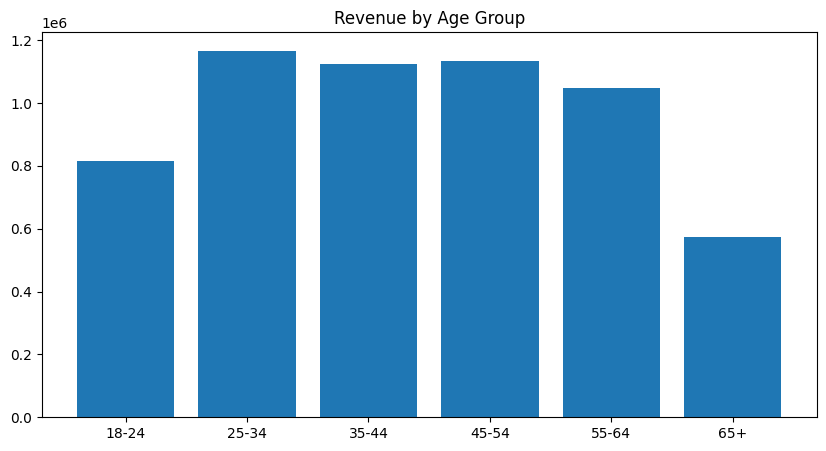

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(by_region.reset_index()["region"], by_region.reset_index()["revenue"])
ax.set_title("Revenue by Region")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(by_payment.reset_index()["payment_method"], by_payment.reset_index()["revenue"])
ax.set_title("Revenue by Payment Method")
plt.xticks(rotation=30)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(by_age.reset_index()["age_group"].astype(str), by_age.reset_index()["revenue"])
ax.set_title("Revenue by Age Group")
plt.show()


### Phát hiện nổi bật
- **South** và **North** dẫn đầu về doanh thu tuyệt đối.
- **East** có thời gian giao hàng trung bình cao hơn, đồng thời return rate cũng không thấp.
- Doanh thu theo phương thức thanh toán khá cân bằng về AOV; **Credit Card** dẫn đầu chủ yếu vì volume giao dịch lớn hơn.
- Theo nhóm tuổi, **25–54** là cụm khách hàng mang lại doanh thu chính; riêng **18–24** có AOV khá cao.


## 7) Discount, shipping cost và rủi ro lợi nhuận

In [13]:
df["discount_band"] = pd.cut(
    df["discount"],
    bins=[-0.001, 0, 0.05, 0.10, 0.15, 1.0],
    labels=["0%", "0-5%", "5-10%", "10-15%", "15%+"]
)

discount_analysis = df.groupby("discount_band", observed=False).agg(
    orders=("order_id", "count"),
    revenue=("total_amount", "sum"),
    avg_order_value=("total_amount", "mean"),
    profit=("profit_margin", "sum"),
    avg_profit=("profit_margin", "mean"),
    return_rate=("returned", lambda s: (s == "Yes").mean()),
    avg_shipping=("shipping_cost", "mean")
)
discount_analysis["profit_rate"] = discount_analysis["profit"] / discount_analysis["revenue"]
discount_analysis


,orders,revenue,avg_order_value,profit,avg_profit,return_rate,avg_shipping,profit_rate
discount_band,,,,,,,,
0%,18939,3388994.91,178.942653,560421.790745,29.590886,0.054121,6.231492,0.165365
0-5%,6176,1022010.29,165.480941,169094.360842,27.379268,0.060233,6.140411,0.165453
5-10%,4159,672166.96,161.617447,109052.422639,26.220828,0.054580,6.090539,0.162240
10-15%,2795,437214.19,156.427259,70485.982035,25.218598,0.057245,5.971814,0.161216
15%+,2431,344906.70,141.878527,54440.792606,22.394403,0.048951,5.876166,0.157842


In [14]:
df["shipping_band"] = pd.qcut(df["shipping_cost"], 5, duplicates="drop")

shipping_analysis = df.groupby("shipping_band", observed=False).agg(
    orders=("order_id", "count"),
    avg_shipping=("shipping_cost", "mean"),
    avg_order_value=("total_amount", "mean"),
    return_rate=("returned", lambda s: (s == "Yes").mean()),
    avg_discount=("discount", "mean"),
    profit_rate=("profit_margin", lambda s: s.sum() / df.loc[s.index, "total_amount"].sum())
)
shipping_analysis


,orders,avg_shipping,avg_order_value,return_rate,avg_discount,profit_rate
shipping_band,,,,,,
"(-0.001, 4.04]",6924,2.868823,11.937269,0.038273,0.054802,0.224916
"(4.04, 5.46]",6917,4.778722,32.251288,0.048287,0.050542,0.235839
"(5.46, 6.75]",6894,6.102901,71.158570,0.056426,0.048499,0.224659
"(6.75, 8.25]",6890,7.464501,157.338795,0.062990,0.047533,0.198813
"(8.25, 15.65]",6875,9.574716,579.625565,0.069964,0.045040,0.142175


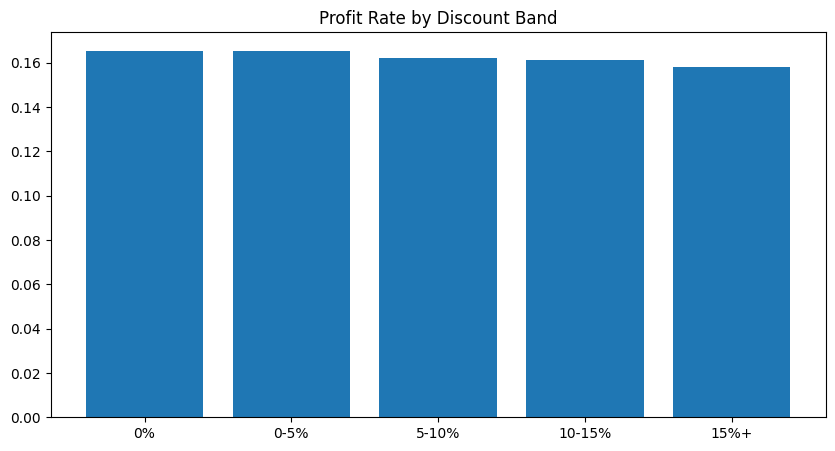

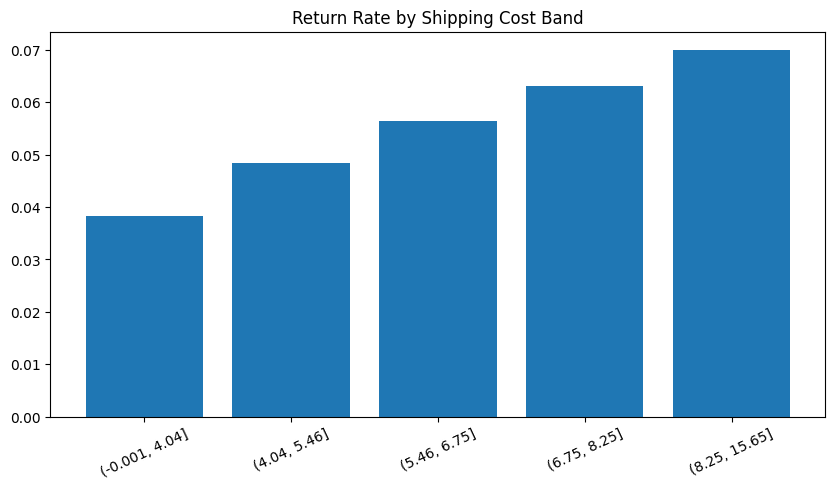

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(discount_analysis.reset_index()["discount_band"].astype(str), discount_analysis.reset_index()["profit_rate"])
ax.set_title("Profit Rate by Discount Band")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(shipping_analysis.reset_index()["shipping_band"].astype(str), shipping_analysis.reset_index()["return_rate"])
ax.set_title("Return Rate by Shipping Cost Band")
plt.xticks(rotation=25)
plt.show()


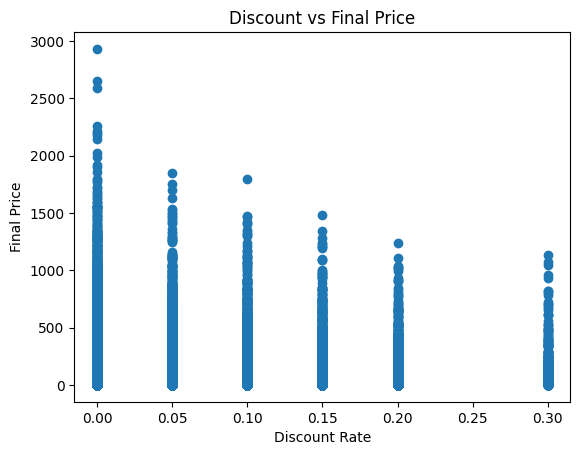

In [16]:
df['final_price'] = df['price'] * (1 - df['discount'])
plt.scatter(df['discount'], df['final_price'])
plt.title("Discount vs Final Price")
plt.xlabel("Discount Rate")
plt.ylabel("Final Price")
plt.show()

### Phát hiện nổi bật
- Khi discount tăng dần, **profit rate giảm dần** khá đều.
- Nhóm **15%+** có biên lợi nhuận thấp nhất.
- Khi shipping cost tăng từ nhóm thấp nhất lên cao nhất, **return rate tăng rõ rệt**.
- Đây là phát hiện rất hữu ích cho use case free-ship:  
  **giảm gánh nặng shipping có thể vừa hỗ trợ chuyển đổi, vừa giảm rủi ro hoàn trả/cảm nhận tiêu cực sau mua**.


## 8) Phân tích đơn hàng lỗ

In [17]:
loss_orders = df[df["profit_margin"] < 0].copy()

loss_summary = {
    "loss_order_count": len(loss_orders),
    "loss_order_rate": len(loss_orders) / len(df),
    "total_negative_profit": loss_orders["profit_margin"].sum(),
    "avg_loss_order_value": loss_orders["total_amount"].mean(),
    "avg_loss_discount": loss_orders["discount"].mean(),
    "avg_loss_shipping": loss_orders["shipping_cost"].mean(),
}
pd.DataFrame({"metric": list(loss_summary.keys()), "value": list(loss_summary.values())})


,metric,value
0,loss_order_count,0.0
1,loss_order_rate,0.0
2,total_negative_profit,0.0
3,avg_loss_order_value,NaN
4,avg_loss_discount,NaN
5,avg_loss_shipping,NaN


In [18]:
loss_by_category = loss_orders.groupby("category").agg(
    loss_orders=("order_id", "count"),
    revenue=("total_amount", "sum"),
    total_loss=("profit_margin", "sum"),
    avg_discount=("discount", "mean"),
    avg_shipping=("shipping_cost", "mean")
).sort_values("loss_orders", ascending=False)

loss_by_region = loss_orders.groupby("region").agg(
    loss_orders=("order_id", "count"),
    total_loss=("profit_margin", "sum")
).sort_values("loss_orders", ascending=False)

display(loss_by_category)
display(loss_by_region)


,loss_orders,revenue,total_loss,avg_discount,avg_shipping
category,,,,,


,loss_orders,total_loss
region,,


### Phát hiện nổi bật
- Tỷ lệ đơn lỗ không nhỏ; đây là **vùng nguy cơ trực tiếp** đối với chiến lược voucher.
- Các nhóm có ticket nhỏ nhưng shipping/discount tương đối cao thường dễ rơi vào trạng thái lợi nhuận âm.
- Trong vận hành thực tế, đây là nơi nên thiết kế rule như:
  - không free-ship toàn phần cho basket quá thấp
  - không áp voucher trên category vốn margin mỏng
  - đặt ngưỡng đơn hàng tối thiểu để kích hoạt ưu đãi


## 9) Mô hình hóa nhanh để đọc hướng tác động

In [19]:
import statsmodels.formula.api as smf

model_revenue = smf.ols(
    'np.log(total_amount) ~ np.log(price) + discount + np.log(shipping_cost + 1) + quantity + C(category) + C(region)',
    data=df
).fit()

model_profit = smf.ols(
    'profit_margin ~ price + discount + shipping_cost + quantity + delivery_time_days + C(category) + C(region)',
    data=df
).fit()

print("Revenue model R^2:", round(model_revenue.rsquared, 4))
print(model_revenue.summary().tables[1])

print("\nProfit model R^2:", round(model_profit.rsquared, 4))
print(model_profit.summary().tables[1])


Revenue model R^2: 0.9961
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -0.5109      0.004   -141.896      0.000      -0.518      -0.504
C(category)[T.Electronics]     0.0016      0.002      0.673      0.501      -0.003       0.006
C(category)[T.Fashion]        -0.0020      0.002     -1.020      0.308      -0.006       0.002
C(category)[T.Grocery]         0.0013      0.002      0.600      0.549      -0.003       0.005
C(category)[T.Home]           -0.0008      0.002     -0.394      0.694      -0.005       0.003
C(category)[T.Sports]         -0.0009      0.002     -0.423      0.672      -0.005       0.003
C(category)[T.Toys]            0.0022      0.002      1.063      0.288      -0.002       0.006
C(region)[T.East]             -0.0025      0.002     -1.464      0.143      -0.006       0.001
C(region)[T.North]      

### Cách đọc đúng phần này
- Đây **không phải causal model**, mà là mô hình đọc nhanh chiều hướng tác động trong EDA.
- Vì dataset là synthetic và `total_amount` được cấu thành cơ học từ price/discount/quantity, nên hệ số ở đây chỉ nên dùng như **directional signal**, không nên diễn giải như elasticity thị trường thật.

### Tóm tắt đọc nhanh
- `discount` đi kèm với **profit_margin thấp hơn**.
- `quantity` và `price` là hai động lực mạnh của `profit_margin`.
- `delivery_time_days` không cho thấy tác động tuyến tính rõ lên lợi nhuận trong bộ dữ liệu này.
